In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import os
import glob
import re

# Set plot style
sns.set_theme(style="whitegrid")

In [86]:
# Helper utilities used across preprocessing cells

def find_column(candidates, df):
    """Return the first matching column name from a list of candidates."""
    for name in candidates:
        if name in df.columns:
            return name
    raise KeyError(f"None of the candidate columns {candidates} were found in the dataframe.")


In [87]:
from pathlib import Path

# Central location for saving charts generated across the notebook
plot_dir = Path('analysis_plots')
plot_dir.mkdir(parents=True, exist_ok=True)


In [88]:
def save_plot(fig, filename, dpi=300):
    """Save matplotlib figure to analysis_plots/ with consistent settings."""
    target_path = plot_dir / filename
    fig.savefig(target_path, dpi=dpi, bbox_inches='tight')
    return target_path


In [89]:
# Load and summarize demographic metadata
demo_path = 'Demographic data.xlsx'
demo_df = pd.read_excel(demo_path)

# Standardize column names
demo_df.columns = (demo_df.columns
                    .str.strip()
                    .str.lower()
                    .str.replace(' ', '_'))

# Harmonize string columns
for col in ['gender', 'handedness', 'vision']:
    demo_df[col] = demo_df[col].astype(str).str.strip().str.title()

# Extract experimental condition from participant ID (suffix _AB or _NB)
demo_df['condition'] = (demo_df['sub_id']
                        .str.extract(r'_([A-Za-z]{2})$', expand=False)
                        .str.upper())

# Descriptive statistics
age_summary = demo_df.groupby('condition')['age'].agg(['count', 'mean', 'std', 'min', 'max']).round(2)
gender_counts = pd.crosstab(demo_df['condition'], demo_df['gender'])
vision_counts = pd.crosstab(demo_df['condition'], demo_df['vision'])
handedness_counts = pd.crosstab(demo_df['condition'], demo_df['handedness'])

print('Demographic sample size:', len(demo_df))
print('Age summary by condition:')
display(age_summary)
print('Gender distribution:')
display(gender_counts)
print('Vision distribution:')   
display(vision_counts)
print('Handedness distribution:')
display(handedness_counts)

# Inferential quick checks
ab_age = demo_df.loc[demo_df['condition'] == 'AB', 'age'].dropna()
nb_age = demo_df.loc[demo_df['condition'] == 'NB', 'age'].dropna()
t_stat, p_t = stats.ttest_ind(ab_age, nb_age, equal_var=False)
print(f'T-test for age differences: t-stat = {t_stat:.2f}, p = {p_t:.3f}')

gender_table = pd.crosstab(demo_df['condition'], demo_df['gender'])
chi2, p_chi, dof, _ = stats.chi2_contingency(gender_table)
print(f'Chi-squared test for gender distribution: chi2 = {chi2:.2f}, p = {p_chi:.3f}, dof = {dof}')

Demographic sample size: 185
Age summary by condition:


,count,mean,std,min,max
condition,,,,,
AB,82,22.34,2.26,19.0,34.0
NB,81,22.26,2.38,19.0,28.0


Gender distribution:


gender,Female,Male
condition,,
AB,27,55
NB,23,58


Vision distribution:


vision,Corrected To Normal,Normal,Uncorrected Vision Difficulty
condition,,,
AB,38,44,0
NB,39,40,2


Handedness distribution:


handedness,Left Handed,Right Handed
condition,,
AB,3,79
NB,6,75


T-test for age differences: t-stat = 0.23, p = 0.821
Chi-squared test for gender distribution: chi2 = 0.21, p = 0.647, dof = 1


/tmp/ipykernel_1319204/629512409.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=demo_df, x='condition', y='age', inner='box', palette='Set2', ax=axes[0])


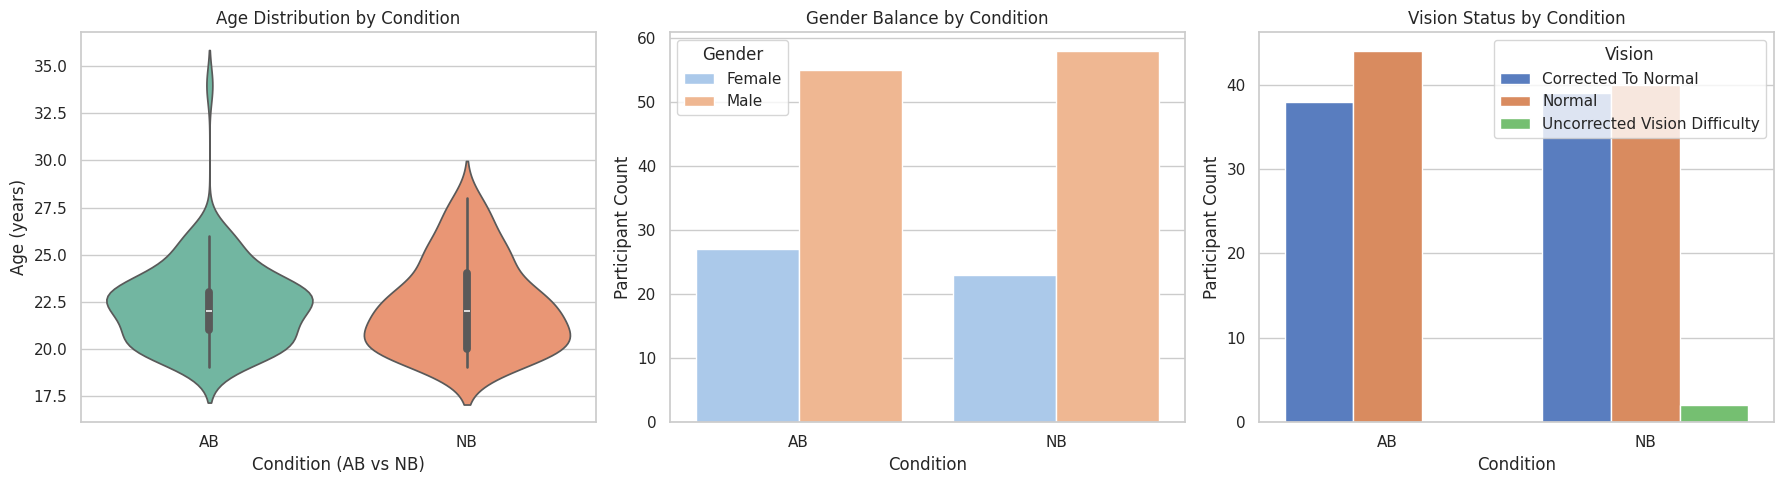

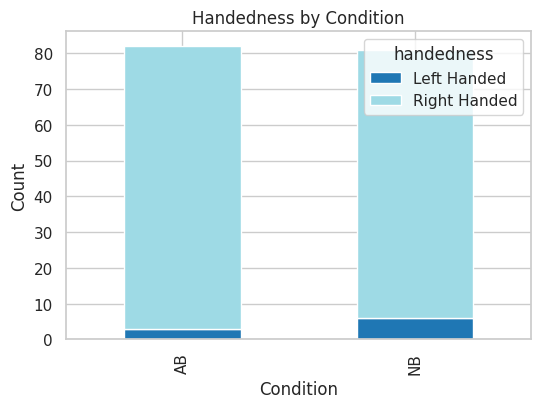

In [90]:
# Visualize demographic distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.violinplot(data=demo_df, x='condition', y='age', inner='box', palette='Set2', ax=axes[0])
axes[0].set_title('Age Distribution by Condition')
axes[0].set_xlabel('Condition (AB vs NB)')
axes[0].set_ylabel('Age (years)')

sns.countplot(data=demo_df, x='condition', hue='gender', palette='pastel', ax=axes[1])
axes[1].set_title('Gender Balance by Condition')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Participant Count')
axes[1].legend(title='Gender')

sns.countplot(data=demo_df, x='condition', hue='vision', palette='muted', ax=axes[2])
axes[2].set_title('Vision Status by Condition')
axes[2].set_xlabel('Condition')
axes[2].set_ylabel('Participant Count')
axes[2].legend(title='Vision')

plt.tight_layout()
plt.show()

if handedness_counts.shape[1] > 1:
    handedness_counts.plot(kind='bar', stacked=True, figsize=(6, 4), colormap='tab20')
    plt.title('Handedness by Condition')
    plt.xlabel('Condition')
    plt.ylabel('Count')
    plt.show()
else:
    print('All recorded participants reported the same handedness, so no additional plot is shown.')

In [91]:

data_dir = 'BRSM data csv'
files = glob.glob(os.path.join(data_dir, '*.csv'))

all_data = []

for file in files:
    try:
        df = pd.read_csv(file)
        
        filename = os.path.basename(file)
        match = re.search(r'(sub\d+)_([A-Z]+)_', filename, re.IGNORECASE)
        if match:
            participant_id = match.group(1)
            condition = match.group(2).upper() 
        else:
            print(f"Skipping file with unexpected name format: {filename}")
            continue
            
        df['participant_id'] = participant_id
        df['condition'] = condition
        
        all_data.append(df)
        
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Concatenate all DataFrames
if all_data:
    combined_df = pd.concat(all_data, ignore_index=True)
    print(f"Loaded {len(all_data)} files into a single DataFrame with {len(combined_df)} rows.")
else:
    print("No data loaded.")

Skipping file with unexpected name format: sub133_AB _recognitionstage_2026-02-02_13h23.31.011.csv
Loaded 170 files into a single DataFrame with 7607 rows.


# Preprocess Data

Filter for valid recognition trials. We expect rows where `recogloop.resp.keys` is populated (or `recogloop.resp.corr`).
We also extract the Target Type (BB/EM) from the `target_img` filename.

In [92]:
if 'recogloop.resp.keys' in combined_df.columns:
    recog_data = combined_df.dropna(subset=['recogloop.resp.keys']).copy()
else:
    print("Warning: 'recogloop.resp.keys' column not found!")
    recog_data = combined_df.copy()

def extract_target_type(path):
    if pd.isna(path):
        return None
    match = re.search(r'_([A-Z]{2})_', str(path))
    if match:
        return match.group(1)
    return None

recog_data['target_type'] = recog_data['target_img'].apply(extract_target_type)

# Check unique target types extracted
print("Extracted Target Types:", recog_data['target_type'].unique())

Extracted Target Types: <StringArray>
['BB', 'EM']
Length: 2, dtype: str


# Visualize Accuracy

We calculate the mean accuracy (`recogloop.resp.corr`) grouped by Condition (AB/NB) and Target Type (BB/EM).

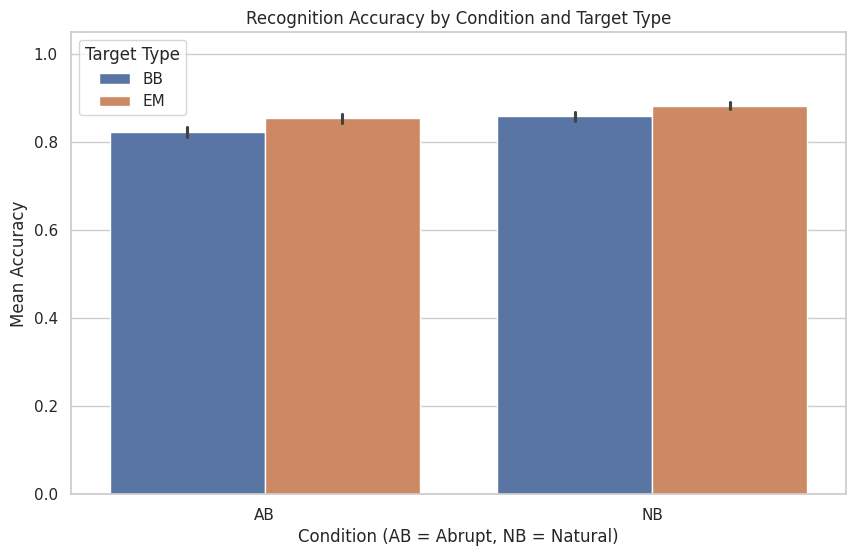

In [93]:
# Calculate mean accuracy per participant first, then average across participants
# Group by participant, condition, target_type
accuracy_per_participant = recog_data.groupby(['participant_id', 'condition', 'target_type'])['recogloop.resp.corr'].mean().reset_index()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=accuracy_per_participant, x='condition', y='recogloop.resp.corr', hue='target_type', errorbar='se')
plt.title('Recognition Accuracy by Condition and Target Type')
plt.ylabel('Mean Accuracy')
plt.xlabel('Condition (AB = Abrupt, NB = Natural)')
plt.ylim(0, 1.05)
plt.legend(title='Target Type')
plt.show()

# Visualize Confidence

We calculate the mean confidence rating (`recogloop.conf_radio.response`) grouped by Condition and Target Type.

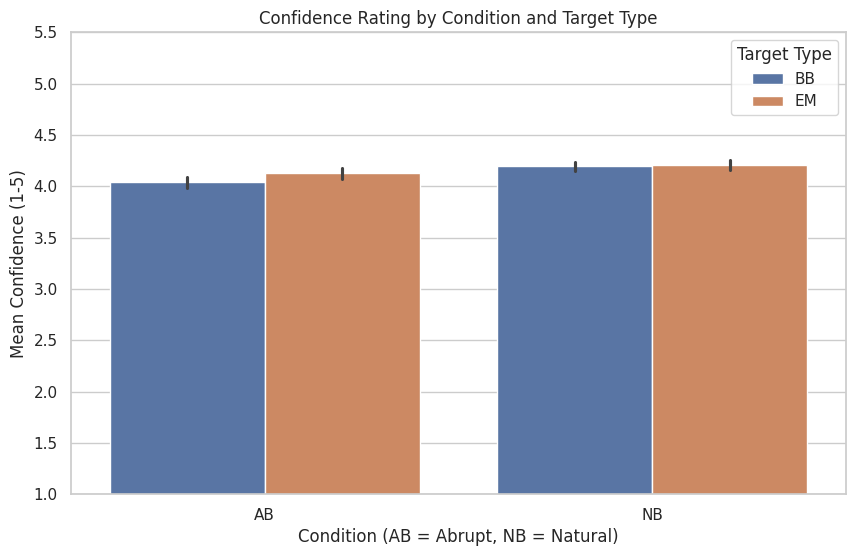

In [94]:
# Calculate mean confidence per participant
if 'recogloop.conf_radio.response' in recog_data.columns:
    confidence_per_participant = recog_data.groupby(['participant_id', 'condition', 'target_type'])['recogloop.conf_radio.response'].mean().reset_index()

    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(data=confidence_per_participant, x='condition', y='recogloop.conf_radio.response', hue='target_type', errorbar='se')
    plt.title('Confidence Rating by Condition and Target Type')
    plt.ylabel('Mean Confidence (1-5)')
    plt.xlabel('Condition (AB = Abrupt, NB = Natural)')
    plt.ylim(1, 5.5)
    plt.legend(title='Target Type')
    plt.show()
else:
    print("Confidence column 'recogloop.conf_radio.response' not found.")

/tmp/ipykernel_1319204/2123515539.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=accuracy_participant,


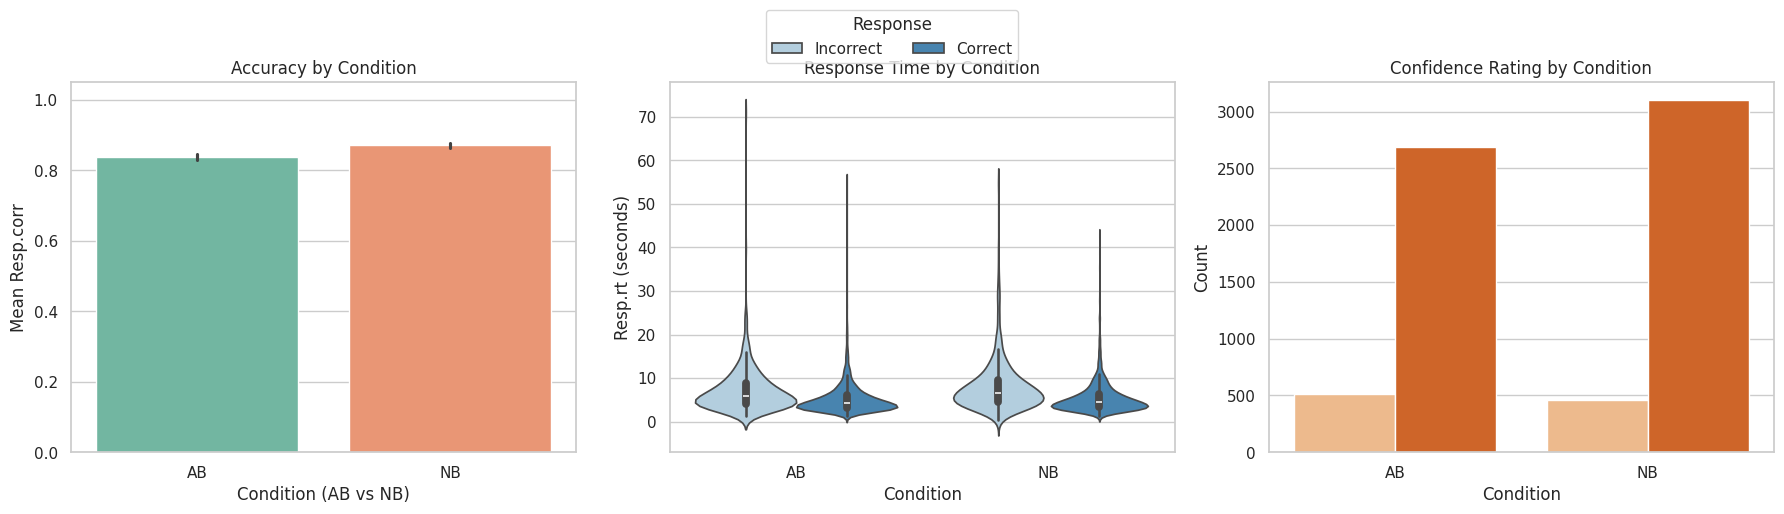

In [95]:
# Summarize Resp.corr, Resp.rt, and Conf_radio.response by condition

import ast

def ensure_scalar(value):
    """Convert PsychoPy list-like response outputs (possibly stored as strings) to scalar floats."""
    if isinstance(value, str):
        stripped = value.strip()
        if stripped.startswith('[') and stripped.endswith(']'):
            try:
                parsed = ast.literal_eval(stripped)
                if isinstance(parsed, (list, tuple)):
                    return parsed[0] if parsed else None
                return parsed
            except (ValueError, SyntaxError):
                return None
        try:
            return float(stripped)
        except ValueError:
            return None
    if isinstance(value, (list, tuple)):
        return value[0] if value else None
    return value

try:
    corr_col = find_column(['recogloop.resp.corr', 'Resp.corr', 'resp.corr'], recog_data)
    rt_col = find_column(['resp.rt', 'Recogloop.resp.rt', 'recogloop.resp.rt'], recog_data)
    conf_col = find_column(['recogloop.conf_radio.response', 'Conf_radio.response', 'conf_radio.response'], recog_data)
except KeyError as err:
    print(err)
else:
    metric_data = recog_data.dropna(subset=[corr_col]).copy()
    metric_data['condition'] = metric_data['condition'].astype('category')
    metric_data['condition'] = metric_data['condition'].cat.set_categories(['AB', 'NB'], ordered=True)

    metric_data['resp_rt_seconds'] = pd.to_numeric(metric_data[rt_col].apply(ensure_scalar), errors='coerce')

    accuracy_participant = (metric_data
                            .groupby(['participant_id', 'condition'])[corr_col]
                            .mean()
                            .reset_index(name='mean_accuracy'))

    metric_data['response_label'] = metric_data[corr_col].apply(lambda val: 'Correct' if val == 1 else 'Incorrect')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.barplot(data=accuracy_participant,
                x='condition',
                y='mean_accuracy',
                errorbar='se',
                palette='Set2',
                ax=axes[0])
    axes[0].set_title('Accuracy by Condition')
    axes[0].set_xlabel('Condition (AB vs NB)')
    axes[0].set_ylabel('Mean Resp.corr')
    axes[0].set_ylim(0, 1.05)

    rt_data = metric_data.dropna(subset=['resp_rt_seconds'])
    sns.violinplot(data=rt_data,
                   x='condition',
                   y='resp_rt_seconds',
                   hue='response_label',
                   palette='Blues',
                   ax=axes[1])
    axes[1].set_title('Response Time by Condition')
    axes[1].set_xlabel('Condition')
    axes[1].set_ylabel('Resp.rt (seconds)')

    handles, labels = axes[1].get_legend_handles_labels()
    if axes[1].legend_:
        axes[1].legend_.remove()

    conf_data = metric_data.dropna(subset=[conf_col])
    sns.countplot(data=conf_data,
                  x='condition',
                  hue='response_label',
                  palette='Oranges',
                  ax=axes[2])
    axes[2].set_title('Confidence Rating by Condition')
    axes[2].set_xlabel('Condition')
    axes[2].set_ylabel('Count')
    if axes[2].legend_:
        axes[2].legend_.remove()
        

    fig.legend(handles, labels, title='Response', loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.04))
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

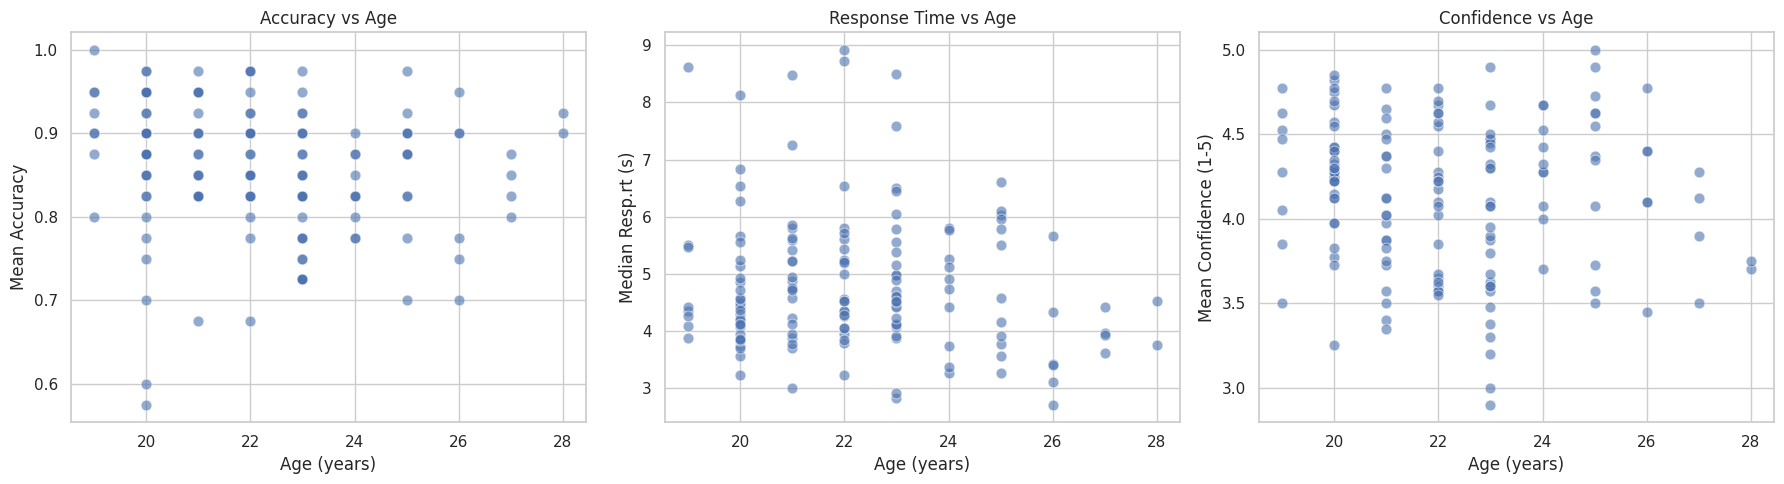

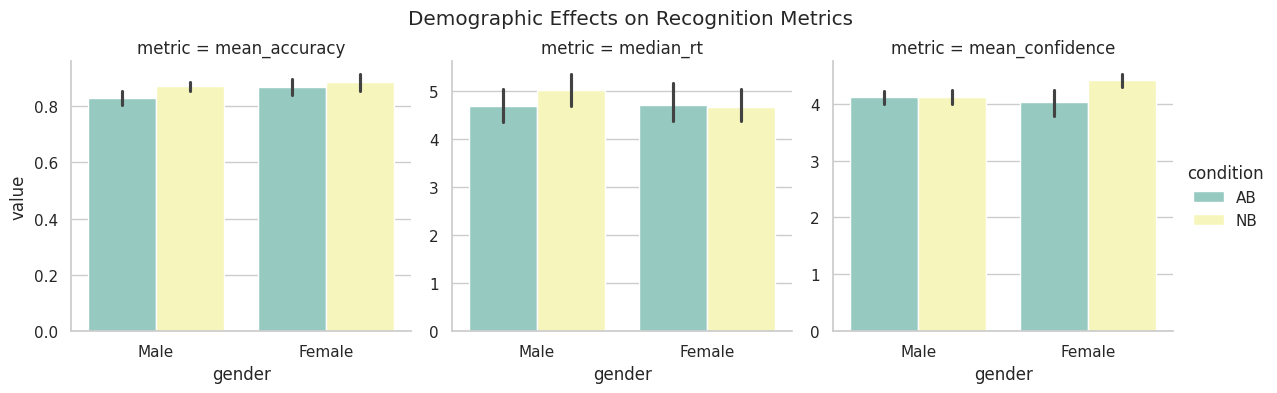

In [96]:

if 'resp_rt_seconds' not in metric_data.columns:
    metric_data['resp_rt_seconds'] = pd.to_numeric(metric_data[rt_col].apply(ensure_scalar), errors='coerce')

numeric_cols = [col for col in [corr_col, conf_col, 'resp_rt_seconds'] if col in metric_data.columns]
metric_data[numeric_cols] = metric_data[numeric_cols].apply(pd.to_numeric, errors='coerce')

demo_aug = demo_df.copy()
demo_aug['participant_base'] = (demo_aug['sub_id']
                                .astype(str)
                                .str.extract(r'(sub\d+)', expand=False)
                                .str.lower())

perf_summary = (metric_data
                .groupby(['participant_id', 'condition'])
                .agg(mean_accuracy=(corr_col, 'mean'),
                     median_rt=('resp_rt_seconds', 'median'),
                     mean_confidence=(conf_col, 'mean'))
                .reset_index())

perf_summary['participant_id'] = perf_summary['participant_id'].str.lower()
demo_aug['condition'] = demo_aug['condition'].str.upper()

demo_perf = perf_summary.merge(
    demo_aug,
    left_on=['participant_id', 'condition'],
    right_on=['participant_base', 'condition'],
    how='left'
)

missing_demo = demo_perf['age'].isna().sum()
if missing_demo:
    print(f'Warning: {missing_demo} participants lack demographic rows; they will be omitted in demographic plots.')

demo_perf = demo_perf.dropna(subset=['age'])

demo_perf[['mean_accuracy', 'median_rt', 'mean_confidence']] = demo_perf[
    ['mean_accuracy', 'median_rt', 'mean_confidence']
].apply(pd.to_numeric, errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=demo_perf, x='age', y='mean_accuracy', ax=axes[0], s=60, alpha=0.6)
axes[0].set_title('Accuracy vs Age')
axes[0].set_ylabel('Mean Accuracy')
axes[0].set_xlabel('Age (years)')

sns.scatterplot(data=demo_perf, x='age', y='median_rt', ax=axes[1], s=60, alpha=0.6)
axes[1].set_title('Response Time vs Age')
axes[1].set_ylabel('Median Resp.rt (s)')
axes[1].set_xlabel('Age (years)')

sns.scatterplot(data=demo_perf, x='age', y='mean_confidence', ax=axes[2], s=60, alpha=0.6)
axes[2].set_title('Confidence vs Age')
axes[2].set_ylabel('Mean Confidence (1-5)')
axes[2].set_xlabel('Age (years)')

plt.tight_layout()
plt.show()

cat_long = demo_perf.melt(
    id_vars=['gender', 'condition'],
    value_vars=['mean_accuracy', 'median_rt', 'mean_confidence'],
    var_name='metric',
    value_name='value'
)

g = sns.catplot(data=cat_long, x='gender', y='value', hue='condition', col='metric',
                kind='bar', height=4, aspect=1, sharey=False, palette='Set3')
g.figure.subplots_adjust(top=0.85)
g.figure.suptitle('Demographic Effects on Recognition Metrics')
plt.show()

## Accuracy, RT, and Sensitivity Analyses

Participant-level summaries for AB vs NB conditions and EM vs BB boundary types. Each section checks distributional assumptions, selects appropriate statistical tests, and favors raincloud-style (violin + box + strip) visualizations over bar charts.

In [97]:
import numpy as np
import ast
from scipy import stats

# Helper utilities for flexible column lookup and PsychoPy scalar conversion

def find_column(candidates, df):
    for name in candidates:
        if name in df.columns:
            return name
    raise KeyError(f"None of the candidate columns {candidates} were found.")


def ensure_scalar(value):
    """Convert list-like PsychoPy exports (e.g., "[0.82]") to plain floats."""
    if isinstance(value, str):
        stripped = value.strip()
        if stripped.startswith('[') and stripped.endswith(']'):
            try:
                parsed = ast.literal_eval(stripped)
                if isinstance(parsed, (list, tuple)):
                    return parsed[0] if parsed else np.nan
                return parsed
            except (ValueError, SyntaxError):
                return np.nan
        try:
            return float(stripped)
        except ValueError:
            return np.nan
    if isinstance(value, (list, tuple)):
        return value[0] if value else np.nan
    return value

accuracy_col = find_column(['recogloop.resp.corr', 'Resp.corr', 'resp.corr'], recog_data)
rt_col = find_column(['recogloop.resp.rt', 'Resp.rt', 'resp.rt'], recog_data)
conf_col = find_column(['recogloop.conf_radio.response', 'Conf_radio.response', 'conf_radio.response'], recog_data)

trial_metrics = (recog_data[[accuracy_col, rt_col, conf_col, 'participant_id', 'condition', 'target_type']]
                 .rename(columns={accuracy_col: 'accuracy', rt_col: 'rt', conf_col: 'confidence'})
                 .copy())

trial_metrics['accuracy'] = pd.to_numeric(trial_metrics['accuracy'], errors='coerce')
trial_metrics['rt'] = pd.to_numeric(trial_metrics['rt'].apply(ensure_scalar), errors='coerce')
trial_metrics['confidence'] = pd.to_numeric(trial_metrics['confidence'].apply(ensure_scalar), errors='coerce')
trial_metrics['condition'] = trial_metrics['condition'].str.upper()

trial_metrics = trial_metrics.dropna(subset=['participant_id', 'condition', 'target_type'])
print(f"Usable recognition trials: {len(trial_metrics):,}")
print('Trials per condition × boundary:')
display(trial_metrics.groupby(['condition', 'target_type']).size().unstack(fill_value=0))

trial_meta_cols = [col for col in recog_data.columns if any(keyword in col.lower() for keyword in ['target', 'lure', 'old', 'new'])]
print('Columns containing target/lure keywords:', trial_meta_cols)

Usable recognition trials: 6,760
Trials per condition × boundary:


target_type,BB,EM
condition,,
AB,1600,1600
NB,1780,1780


Columns containing target/lure keywords: ['target_img', 'lure_img', 'target_type']


In [98]:
print('Proportion of missing values in target/lure columns:')
missing_summary = recog_data[['target_img', 'lure_img']].isna().mean().round(3)
display(missing_summary)
print('Example rows showing target and lure file names (first 3 trials):')
display(recog_data[['target_img', 'lure_img', 'recogloop.resp.corr']].head(3))

Proportion of missing values in target/lure columns:


target_img    0.0
lure_img      0.0
dtype: float64

Example rows showing target and lure file names (first 3 trials):


,target_img,lure_img,recogloop.resp.corr
4,frames\Vid13_BB_T.png,frames\Vid13_L.png,0.0
5,frames\Vid24_BB_T.png,frames\Vid24_L.png,1.0
6,frames\Vid5_EM_T.png,frames\Vid5_L.png,1.0


In [99]:
print('Columns available in recognition dataframe (subset):')
col_list = sorted(recog_data.columns)
print(col_list)

Columns available in recognition dataframe (subset):
['ISI.started', 'ISI.stopped', 'Instructions.started', 'Instructions.stopped', 'Unnamed: 100', 'Unnamed: 102', 'Unnamed: 104', 'Unnamed: 21', 'Videos.started', 'Videos.stopped', 'age', 'alcohol_smoke_12h', 'caffeine_2h', 'condition', 'conf_label.started', 'conf_radio.response', 'conf_radio.rt', 'conf_radio.started', 'conf_text.started', 'confidence', 'confidence.started', 'confidence.stopped', 'confidence_rt', 'date', 'demographics.started', 'demographics.stopped', 'duration', 'expName', 'expStart', 'expVersion', 'frameRate', 'frames_question.started', 'gender', 'handedness', 'instruction_2.started', 'instruction_2.stopped', 'is_repeat', 'key_resp.duration', 'key_resp.keys', 'key_resp.rt', 'key_resp.started', 'key_resp_2.duration', 'key_resp_2.keys', 'key_resp_2.rt', 'key_resp_2.started', 'key_resp_3.duration', 'key_resp_3.keys', 'key_resp_3.rt', 'key_resp_3.started', 'key_resp_4.duration', 'key_resp_4.keys', 'key_resp_4.rt', 'key_re

### AB vs NB accuracy and response time

Participant counts per condition:


condition
AB    80
NB    89
Name: participant_id, dtype: int64

,metric,description,test,statistic,p_value,AB_mean,NB_mean,normality_p_AB,normality_p_NB
0,mean_accuracy,Mean accuracy,Mann-Whitney U,2714.5,0.007385,0.838750,0.871348,0.007692,0.000452
1,median_rt,Median RT (s),Mann-Whitney U,3190.0,0.244655,4.717957,4.903657,0.000005,0.000338


/tmp/ipykernel_1319204/1081296798.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=condition_metrics, x='condition', y=metric, palette='pastel', inner=None, ax=ax)
/tmp/ipykernel_1319204/1081296798.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=condition_metrics, x='condition', y=metric, palette='pastel', inner=None, ax=ax)


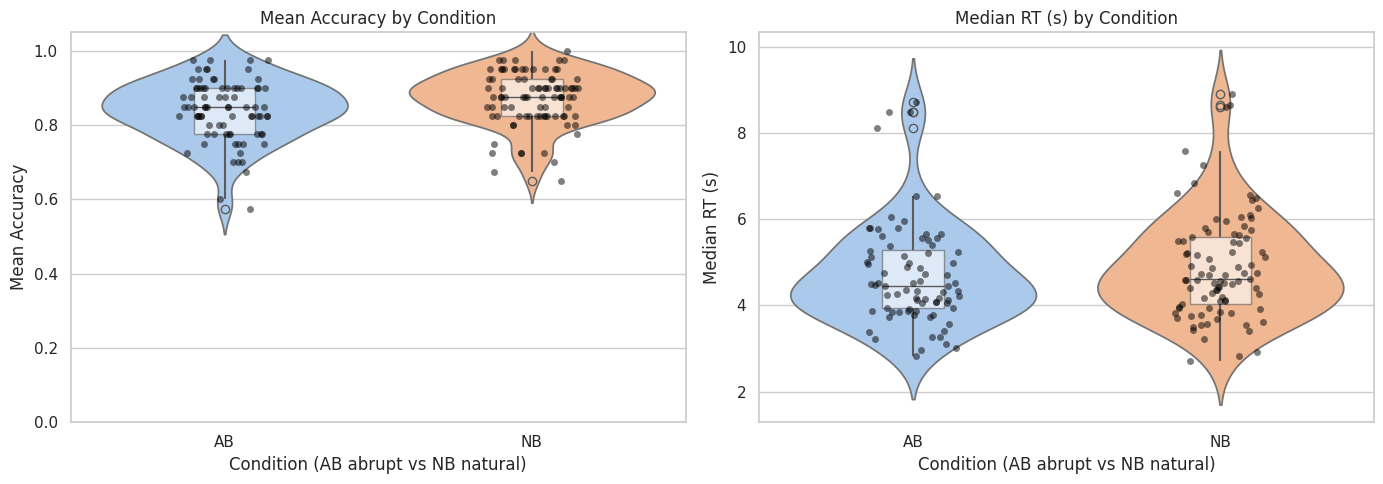

In [100]:
condition_metrics = (trial_metrics
                     .groupby(['participant_id', 'condition'])
                     .agg(mean_accuracy=('accuracy', 'mean'),
                          median_rt=('rt', 'median'),
                          mean_confidence=('confidence', 'mean'),
                          trial_count=('accuracy', 'size'))
                     .reset_index())

print('Participant counts per condition:')
display(condition_metrics.groupby('condition')['participant_id'].nunique())

def normality_summary(data):
    data = data.dropna()
    if len(data) < 3:
        return np.nan, np.nan
    stat, p = stats.shapiro(data)
    return stat, p

condition_tests = []
for metric, label in [('mean_accuracy', 'Mean accuracy'), ('median_rt', 'Median RT (s)')]:
    samples = {cond: grp[metric].dropna() for cond, grp in condition_metrics.groupby('condition')}
    normals = {cond: normality_summary(vals) for cond, vals in samples.items()}
    all_normal = all((p is not np.nan) and (p > 0.05) for _, (_, p) in normals.items())
    sufficient = all(len(vals) >= 5 for vals in samples.values())
    if all_normal and sufficient:
        stat_val, p_val = stats.ttest_ind(samples.get('AB', pd.Series()),
                                          samples.get('NB', pd.Series()),
                                          equal_var=False, nan_policy='omit')
        test_name = "Welch's t"
    else:
        stat_val, p_val = stats.mannwhitneyu(samples.get('AB', pd.Series()),
                                             samples.get('NB', pd.Series()),
                                             alternative='two-sided')
        test_name = 'Mann-Whitney U'
    condition_tests.append({
        'metric': metric,
        'description': label,
        'test': test_name,
        'statistic': stat_val,
        'p_value': p_val,
        'AB_mean': samples.get('AB', pd.Series()).mean(),
        'NB_mean': samples.get('NB', pd.Series()).mean(),
        'normality_p_AB': normals.get('AB', (np.nan, np.nan))[1],
        'normality_p_NB': normals.get('NB', (np.nan, np.nan))[1]
    })

condition_results = pd.DataFrame(condition_tests)
display(condition_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_pairs = [('mean_accuracy', 'Mean Accuracy', (0, 1.05)), ('median_rt', 'Median RT (s)', None)]
for ax, (metric, ylabel, ylim) in zip(axes, plot_pairs):
    sns.violinplot(data=condition_metrics, x='condition', y=metric, palette='pastel', inner=None, ax=ax)
    sns.boxplot(data=condition_metrics, x='condition', y=metric, width=0.2, showcaps=False, boxprops={'facecolor': 'white', 'alpha': 0.6},
                whiskerprops={'linewidth': 1.5}, ax=ax)
    sns.stripplot(data=condition_metrics, x='condition', y=metric, color='black', alpha=0.5, jitter=0.15, ax=ax)
    ax.set_title(f'{ylabel} by Condition')
    ax.set_xlabel('Condition (AB abrupt vs NB natural)')
    ax.set_ylabel(ylabel)
    if ylim:
        ax.set_ylim(*ylim)

plt.tight_layout()
plt.show()

### EM vs BB boundary effects (within-participant)

,metric,test,statistic,p_value,diff_mean (BB-EM),normality_p_diff
0,mean_accuracy,Wilcoxon signed-rank,3040.000000,0.002076,-0.027811,0.001023
1,median_rt,Paired t,3.749406,0.000244,0.245253,0.130711


/tmp/ipykernel_1319204/4213030711.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='target_type', y='value', palette='coolwarm', inner=None, ax=ax)
/tmp/ipykernel_1319204/4213030711.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='target_type', y='value', palette='coolwarm', inner=None, ax=ax)


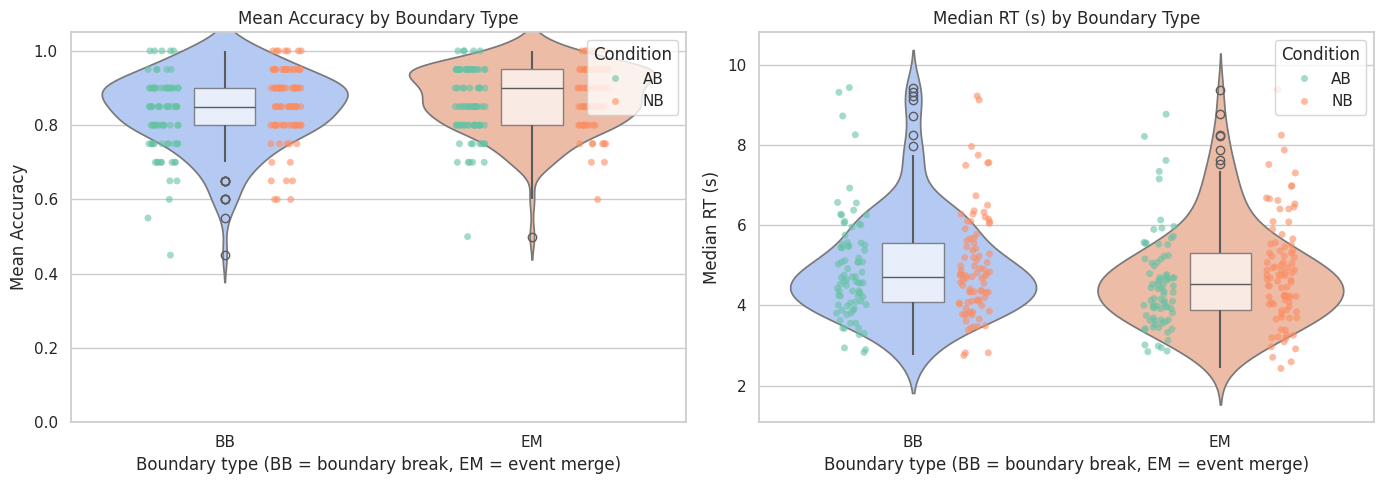

In [101]:
boundary_metrics = (trial_metrics
                     .groupby(['participant_id', 'condition', 'target_type'])
                     .agg(mean_accuracy=('accuracy', 'mean'),
                          median_rt=('rt', 'median'),
                          mean_confidence=('confidence', 'mean'),
                          trial_count=('accuracy', 'size'))
                     .reset_index())

pivot_acc = boundary_metrics.pivot_table(index='participant_id', columns='target_type', values='mean_accuracy')
pivot_rt = boundary_metrics.pivot_table(index='participant_id', columns='target_type', values='median_rt')

pairwise_tests = []
for pivot_df, metric in [(pivot_acc, 'mean_accuracy'), (pivot_rt, 'median_rt')]:
    available = pivot_df.dropna()
    if available.empty:
        pairwise_tests.append({'metric': metric, 'test': 'n/a', 'statistic': np.nan, 'p_value': np.nan})
        continue
    diff = (available['BB'] - available['EM']).dropna()
    norm_stat, norm_p = stats.shapiro(diff) if len(diff) >= 3 else (np.nan, np.nan)
    if norm_p is not np.nan and norm_p > 0.05 and len(diff) >= 5:
        stat_val, p_val = stats.ttest_rel(available['BB'], available['EM'], nan_policy='omit')
        test_name = 'Paired t'
    else:
        stat_val, p_val = stats.wilcoxon(available['BB'], available['EM'])
        test_name = 'Wilcoxon signed-rank'
    pairwise_tests.append({
        'metric': metric,
        'test': test_name,
        'statistic': stat_val,
        'p_value': p_val,
        'diff_mean (BB-EM)': diff.mean(),
        'normality_p_diff': norm_p
    })

display(pd.DataFrame(pairwise_tests))

boundary_long = boundary_metrics.melt(id_vars=['participant_id', 'condition', 'target_type'],
                                      value_vars=['mean_accuracy', 'median_rt'],
                                      var_name='metric', value_name='value')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (metric, title, ylim) in zip(axes,
                                     [('mean_accuracy', 'Mean Accuracy', (0, 1.05)),
                                      ('median_rt', 'Median RT (s)', None)]):
    plot_data = boundary_long[boundary_long['metric'] == metric]
    sns.violinplot(data=plot_data, x='target_type', y='value', palette='coolwarm', inner=None, ax=ax)
    sns.boxplot(data=plot_data, x='target_type', y='value', width=0.2, showcaps=False,
                boxprops={'facecolor': 'white', 'alpha': 0.7}, whiskerprops={'linewidth': 1.5}, ax=ax)
    sns.stripplot(data=plot_data, x='target_type', y='value', hue='condition', dodge=True,
                  palette='Set2', alpha=0.6, ax=ax)
    ax.set_title(f'{title} by Boundary Type')
    ax.set_xlabel('Boundary type (BB = boundary break, EM = event merge)')
    ax.set_ylabel(title)
    if ylim:
        ax.set_ylim(*ylim)
    if ax.get_legend():
        ax.legend(title='Condition', loc='upper right')

plt.tight_layout()
plt.show()

### D-prime computation (sensitivity to hits vs false alarms)

AB vs NB d'-prime test:
{'test': "Welch's t", 'statistic': np.float64(-2.709713915852664), 'p_value': np.float64(0.0074441463188916705), 'AB_mean': np.float64(1.4270349747390436), 'NB_mean': np.float64(1.6282510507924015), 'normality_p_AB': np.float64(0.10507662522538797), 'normality_p_NB': np.float64(0.05032646585583568)}

Boundary-level d'-prime test:
{'test': 'Wilcoxon signed-rank', 'statistic': np.float64(3125.0), 'p_value': np.float64(0.004065881875223241), 'diff_mean (BB-EM)': np.float64(-0.14956239079504452), 'normality_p_diff': np.float64(0.04130399617073446)}


/tmp/ipykernel_1319204/2514359230.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x=x_label, y='dprime', inner=None, palette='viridis', ax=ax)
/tmp/ipykernel_1319204/2514359230.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x=x_label, y='dprime', inner=None, palette='viridis', ax=ax)


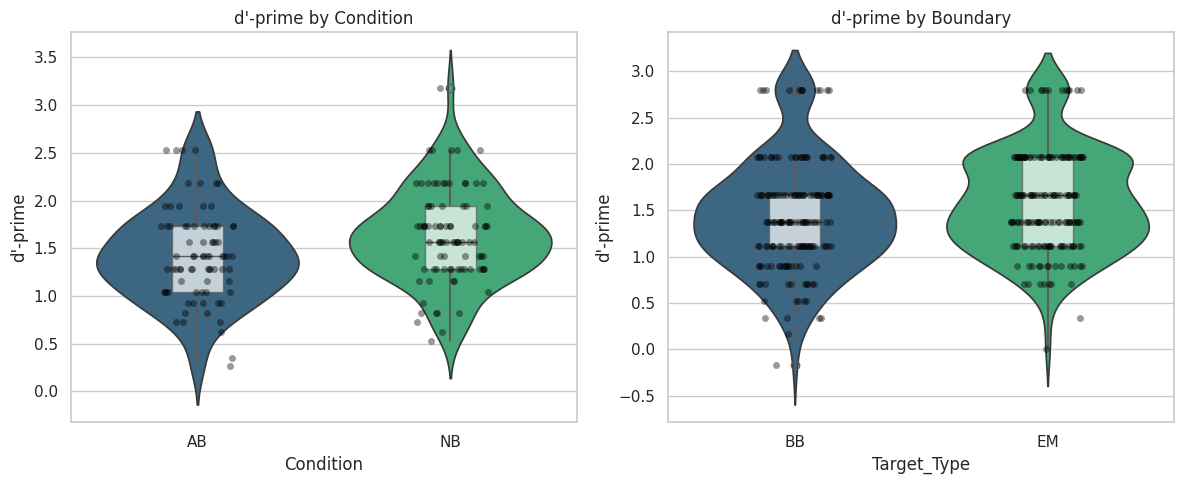

In [102]:
from math import sqrt

def two_afc_dprime(prop_correct, n_trials):
    if pd.isna(prop_correct) or pd.isna(n_trials) or n_trials == 0:
        return np.nan
    adj = ((prop_correct * n_trials) + 0.5) / (n_trials + 1)
    adj = min(max(adj, 1e-4), 1 - 1e-4)
    return sqrt(2) * stats.norm.ppf(adj)

condition_metrics['dprime'] = condition_metrics.apply(
    lambda row: two_afc_dprime(row['mean_accuracy'], row['trial_count']), axis=1)
boundary_metrics['dprime'] = boundary_metrics.apply(
    lambda row: two_afc_dprime(row['mean_accuracy'], row['trial_count']), axis=1)

# Condition-level sensitivity comparison
samples_dprime = {cond: grp['dprime'].dropna() for cond, grp in condition_metrics.groupby('condition')}
normality_dp = {cond: normality_summary(vals) for cond, vals in samples_dprime.items()}
all_normal_dp = all((p is not np.nan) and (p > 0.05) for _, (_, p) in normality_dp.items())
if all_normal_dp:
    dp_stat, dp_p = stats.ttest_ind(samples_dprime.get('AB', pd.Series()),
                                    samples_dprime.get('NB', pd.Series()),
                                    equal_var=False, nan_policy='omit')
    dp_test_name = "Welch's t"
else:
    dp_stat, dp_p = stats.mannwhitneyu(samples_dprime.get('AB', pd.Series()),
                                        samples_dprime.get('NB', pd.Series()),
                                        alternative='two-sided')
    dp_test_name = 'Mann-Whitney U'

print('AB vs NB d\'-prime test:')
print({'test': dp_test_name, 'statistic': dp_stat, 'p_value': dp_p,
       'AB_mean': samples_dprime.get('AB', pd.Series()).mean(),
       'NB_mean': samples_dprime.get('NB', pd.Series()).mean(),
       'normality_p_AB': normality_dp.get('AB', (np.nan, np.nan))[1],
       'normality_p_NB': normality_dp.get('NB', (np.nan, np.nan))[1]})

pivot_dp = boundary_metrics.pivot_table(index='participant_id', columns='target_type', values='dprime').dropna()
if not pivot_dp.empty:
    dp_diff = (pivot_dp['BB'] - pivot_dp['EM']).dropna()
    norm_dp_stat, norm_dp_p = stats.shapiro(dp_diff) if len(dp_diff) >= 3 else (np.nan, np.nan)
    if norm_dp_p is not np.nan and norm_dp_p > 0.05 and len(dp_diff) >= 5:
        dp_pair_stat, dp_pair_p = stats.ttest_rel(pivot_dp['BB'], pivot_dp['EM'])
        dp_pair_test = 'Paired t'
    else:
        dp_pair_stat, dp_pair_p = stats.wilcoxon(pivot_dp['BB'], pivot_dp['EM'])
        dp_pair_test = 'Wilcoxon signed-rank'
    print('\nBoundary-level d\'-prime test:')
    print({'test': dp_pair_test, 'statistic': dp_pair_stat, 'p_value': dp_pair_p,
           'diff_mean (BB-EM)': dp_diff.mean(), 'normality_p_diff': norm_dp_p})
else:
    print('Insufficient paired data to test boundary-level d\'-prime differences.')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, x_label, title in [
    (axes[0], condition_metrics, 'condition', "d'-prime by Condition"),
    (axes[1], boundary_metrics, 'target_type', "d'-prime by Boundary")]:
    sns.violinplot(data=data, x=x_label, y='dprime', inner=None, palette='viridis', ax=ax)
    sns.boxplot(data=data, x=x_label, y='dprime', width=0.2, showcaps=False,
                boxprops={'facecolor': 'white', 'alpha': 0.7}, whiskerprops={'linewidth': 1.5}, ax=ax)
    sns.stripplot(data=data, x=x_label, y='dprime', color='black', alpha=0.4, jitter=0.15, ax=ax)
    ax.set_ylabel("d'-prime")
    ax.set_xlabel(x_label.title())
    ax.set_title(title)
plt.tight_layout()
plt.show()

### Confidence as a predictor of accuracy/RT

,condition,spearman_r (conf vs acc),p (conf vs acc),spearman_r (conf vs rt),p (conf vs rt)
0,AB,0.314967,0.004433,-0.213230,0.057555
1,NB,0.368634,0.000379,-0.198039,0.062835


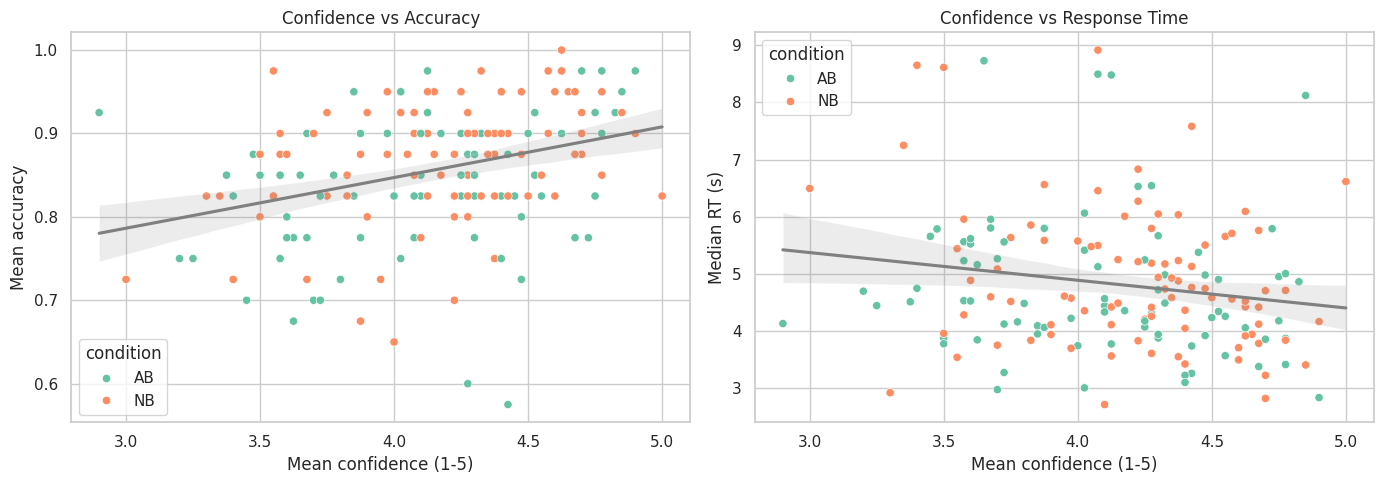

In [103]:
confidence_df = condition_metrics.dropna(subset=['mean_confidence'])

corr_rows = []
for cond, sub in confidence_df.groupby('condition'):
    if len(sub) < 5:
        continue
    acc_corr = stats.spearmanr(sub['mean_confidence'], sub['mean_accuracy'], nan_policy='omit')
    rt_corr = stats.spearmanr(sub['mean_confidence'], sub['median_rt'], nan_policy='omit')
    corr_rows.append({'condition': cond,
                      'spearman_r (conf vs acc)': acc_corr.statistic,
                      'p (conf vs acc)': acc_corr.pvalue,
                      'spearman_r (conf vs rt)': rt_corr.statistic,
                      'p (conf vs rt)': rt_corr.pvalue})

display(pd.DataFrame(corr_rows))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=confidence_df, x='mean_confidence', y='mean_accuracy', hue='condition', palette='Set2', ax=axes[0])
sns.regplot(data=confidence_df, x='mean_confidence', y='mean_accuracy', scatter=False, color='gray', ax=axes[0])
axes[0].set_xlabel('Mean confidence (1-5)')
axes[0].set_ylabel('Mean accuracy')
axes[0].set_title('Confidence vs Accuracy')

sns.scatterplot(data=confidence_df, x='mean_confidence', y='median_rt', hue='condition', palette='Set2', ax=axes[1])
sns.regplot(data=confidence_df, x='mean_confidence', y='median_rt', scatter=False, color='gray', ax=axes[1])
axes[1].set_xlabel('Mean confidence (1-5)')
axes[1].set_ylabel('Median RT (s)')
axes[1].set_title('Confidence vs Response Time')

plt.tight_layout()
plt.show()

## Demographics × Recognition Outcomes

Fuse the demographic sheet with participant-level recognition metrics to see whether age, gender, or other background factors modulate accuracy, response time, or confidence.


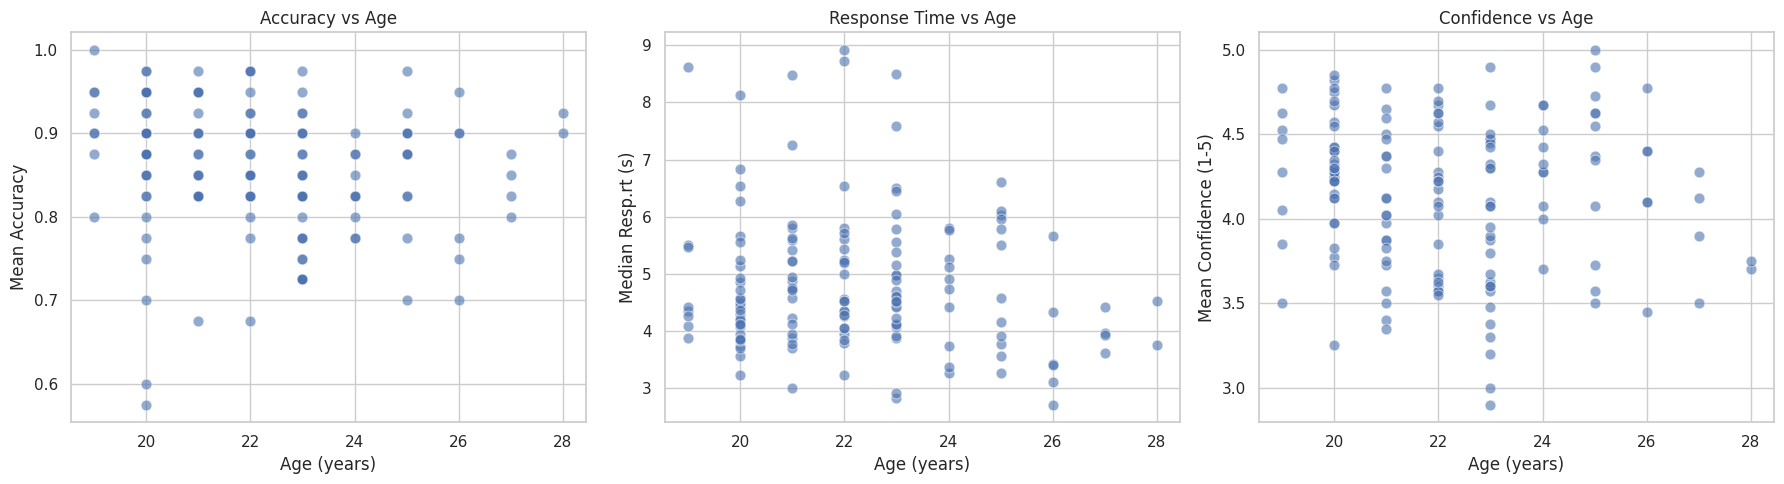

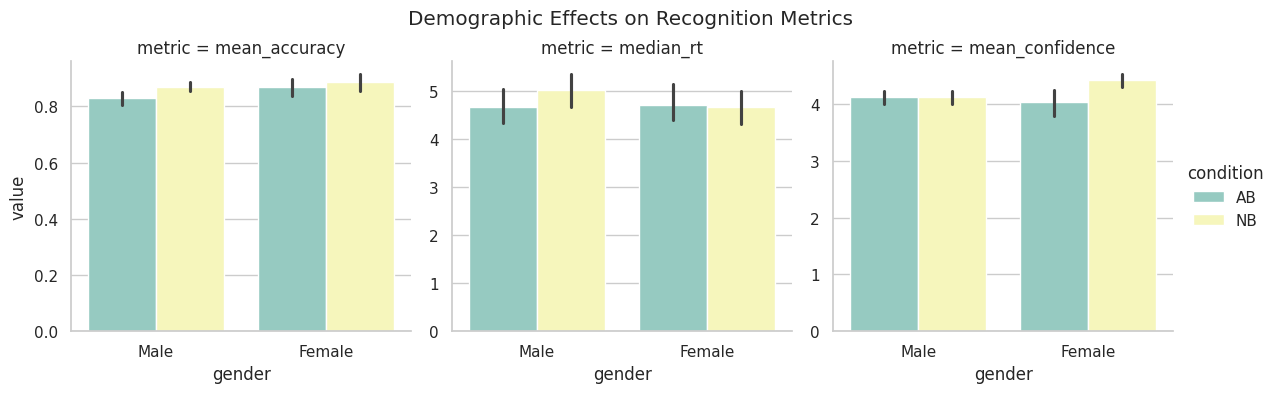

In [104]:
# Merge demographic metadata with participant-level recognition summaries

if 'resp_rt_seconds' not in metric_data.columns:
    metric_data['resp_rt_seconds'] = pd.to_numeric(metric_data[rt_col].apply(ensure_scalar), errors='coerce')

numeric_cols = [col for col in [corr_col, conf_col, 'resp_rt_seconds'] if col in metric_data.columns]
metric_data[numeric_cols] = metric_data[numeric_cols].apply(pd.to_numeric, errors='coerce')

demo_aug = demo_df.copy()
demo_aug['participant_base'] = (demo_aug['sub_id']
                                .astype(str)
                                .str.extract(r'(sub\d+)', expand=False)
                                .str.lower())

perf_summary = (metric_data
                .groupby(['participant_id', 'condition'])
                .agg(mean_accuracy=(corr_col, 'mean'),
                     median_rt=('resp_rt_seconds', 'median'),
                     mean_confidence=(conf_col, 'mean'))
                .reset_index())

perf_summary['participant_id'] = perf_summary['participant_id'].str.lower()
demo_aug['condition'] = demo_aug['condition'].str.upper()

demo_perf = perf_summary.merge(
    demo_aug,
    left_on=['participant_id', 'condition'],
    right_on=['participant_base', 'condition'],
    how='left'
)

missing_demo = demo_perf['age'].isna().sum()
if missing_demo:
    print(f'Warning: {missing_demo} participants lack demographic rows; they will be omitted in demographic plots.')

demo_perf = demo_perf.dropna(subset=['age'])

demo_perf[['mean_accuracy', 'median_rt', 'mean_confidence']] = demo_perf[
    ['mean_accuracy', 'median_rt', 'mean_confidence']
].apply(pd.to_numeric, errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=demo_perf, x='age', y='mean_accuracy', ax=axes[0], s=60, alpha=0.6)
axes[0].set_title('Accuracy vs Age')
axes[0].set_ylabel('Mean Accuracy')
axes[0].set_xlabel('Age (years)')

sns.scatterplot(data=demo_perf, x='age', y='median_rt', ax=axes[1], s=60, alpha=0.6)
axes[1].set_title('Response Time vs Age')
axes[1].set_ylabel('Median Resp.rt (s)')
axes[1].set_xlabel('Age (years)')

sns.scatterplot(data=demo_perf, x='age', y='mean_confidence', ax=axes[2], s=60, alpha=0.6)
axes[2].set_title('Confidence vs Age')
axes[2].set_ylabel('Mean Confidence (1-5)')
axes[2].set_xlabel('Age (years)')

plt.tight_layout()
plt.show()

cat_long = demo_perf.melt(
    id_vars=['gender', 'condition'],
    value_vars=['mean_accuracy', 'median_rt', 'mean_confidence'],
    var_name='metric',
    value_name='value'
)

g = sns.catplot(data=cat_long, x='gender', y='value', hue='condition', col='metric',
                kind='bar', height=4, aspect=1, sharey=False, palette='Set3')
g.figure.subplots_adjust(top=0.85)
g.figure.suptitle('Demographic Effects on Recognition Metrics')
plt.show()


Encoding vigilance threshold = 27.05 min (includes 5.6 min repeats + 25s skip buffer per repeat).


,participant_id,condition,encoding_minutes,attention_flag,overage_minutes
0,Sub41,AB,0.0,≤ 27.05 min,-27.05
1,Sub43,NB,0.0,≤ 27.05 min,-27.05
2,sub100,AB,0.0,≤ 27.05 min,-27.05
3,sub101,AB,0.0,≤ 27.05 min,-27.05
4,sub102,AB,0.0,≤ 27.05 min,-27.05
5,sub103,AB,0.0,≤ 27.05 min,-27.05
6,sub104,AB,0.0,≤ 27.05 min,-27.05
7,sub105,AB,0.0,≤ 27.05 min,-27.05
8,sub106,AB,0.0,≤ 27.05 min,-27.05
9,sub107,AB,0.0,≤ 27.05 min,-27.05



Vigilance counts by condition:


attention_flag,≤ 27.05 min
condition,
AB,80
NB,89



Vigilance percentages by condition:


attention_flag,≤ 27.05 min
condition,
AB,100.0
NB,100.0



Overall percentage of vigilant participants: 100.0%


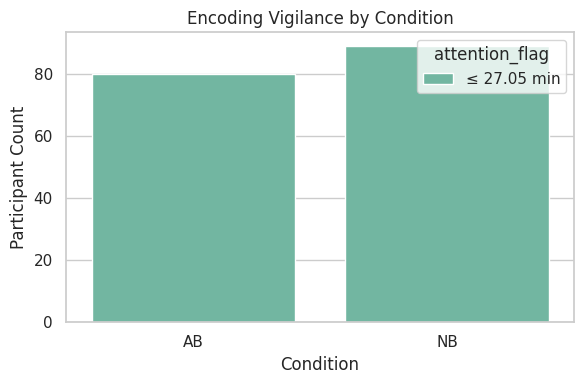

In [105]:
# Evaluate encoding-stage vigilance from the instruction-to-video window
required_cols = {'instruction_2.stopped', 'Videos.stopped'}
missing_cols = [col for col in required_cols if col not in combined_df.columns]
if missing_cols:
    print(f"Cannot compute vigilance because columns are missing: {missing_cols}")
else:
    time_subset = combined_df[['participant_id', 'condition', 'instruction_2.stopped', 'Videos.stopped']].copy()
    time_subset['instruction_stop_dt'] = pd.to_datetime(time_subset['instruction_2.stopped'], errors='coerce')
    time_subset['video_stop_dt'] = pd.to_datetime(time_subset['Videos.stopped'], errors='coerce')
    
    vigilance = (time_subset
                 .groupby(['participant_id', 'condition'])
                 .agg(encoding_start=('instruction_stop_dt', 'min'),
                      encoding_end=('video_stop_dt', 'max'))
                 .reset_index())
    vigilance = vigilance.dropna(subset=['encoding_start', 'encoding_end'])
    
    if vigilance.empty:
        print('No complete encoding windows were available to score vigilance.')
    else:
        vigilance['encoding_minutes'] = ((vigilance['encoding_end'] - vigilance['encoding_start'])
                                         .dt.total_seconds() / 60).round(2)
        
        REPEATED_VIDEOS_MIN = 5.6  # Total time occupied by the five repeat clips
        REPEAT_SKIP_SEC = 25         # Buffer assumed per repeat before participants skipped
        ENCODING_THRESHOLD_MIN = 27.05
        
        vigilance['attentive'] = vigilance['encoding_minutes'] <= ENCODING_THRESHOLD_MIN
        vigilance['attention_flag'] = vigilance['attentive'].map({True: '≤ 27.05 min', False: '> 27.05 min'})
        vigilance['overage_minutes'] = (vigilance['encoding_minutes'] - ENCODING_THRESHOLD_MIN).round(2)
        
        print("Encoding vigilance threshold = "
              f"{ENCODING_THRESHOLD_MIN} min (includes {REPEATED_VIDEOS_MIN} min repeats + "
              f"{REPEAT_SKIP_SEC}s skip buffer per repeat).")
        display_cols = ['participant_id', 'condition', 'encoding_minutes', 'attention_flag', 'overage_minutes']
        display(vigilance.sort_values('encoding_minutes', ascending=False)[display_cols].head(20))
        
        flagged = vigilance.loc[~vigilance['attentive']]
        if not flagged.empty:
            print('\nParticipants exceeding the vigilance window:')
            display(flagged.sort_values('encoding_minutes', ascending=False)[display_cols])
        
        vigilance_summary = (vigilance
                             .groupby(['condition', 'attention_flag'])
                             .size()
                             .unstack(fill_value=0)
                             .astype(int))
        print('\nVigilance counts by condition:')
        display(vigilance_summary)
        
        # Calculate and print percentages
        vigilance_pct = vigilance_summary.div(vigilance_summary.sum(axis=1), axis=0) * 100
        print('\nVigilance percentages by condition:')
        display(vigilance_pct.round(2))
        
        overall_vigilant_pct = (vigilance['attentive'].sum() / len(vigilance) * 100)
        print(f'\nOverall percentage of vigilant participants: {overall_vigilant_pct:.1f}%')
        
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.countplot(data=vigilance, x='condition', hue='attention_flag', palette='Set2', ax=ax)
        ax.set_title('Encoding Vigilance by Condition')
        ax.set_xlabel('Condition')
        ax.set_ylabel('Participant Count')
        plt.tight_layout()
        plt.show()

## REC & LDI Indices

We adapt mnemonic-similarity metrics to the forced-choice design by treating each recognition trial as a hit (target selected) or false alarm (lure selected). The Recognition Index (REC) is computed as the hit rate minus the false-alarm rate using a log-linear correction to avoid ceiling/floor artifacts. To approximate a lure-discrimination signal (LDI) with the available factors, we contrast accuracy for before-boundary (BB) versus event-middle (EM) targets, interpreting higher BB accuracy as better discrimination between overlapping lure content. All assumptions are noted in the narrative below the plots.

Participant-level REC/LDI preview:


,participant_id,condition,n_trials,hit_rate,false_alarm_rate,rec_index,bb_accuracy,em_accuracy,ldi
0,Sub41,AB,40,0.850,0.150,0.682927,0.80,0.90,-0.10
1,Sub43,NB,40,0.925,0.075,0.829268,1.00,0.85,0.15
2,sub100,AB,40,0.975,0.025,0.926829,1.00,0.95,0.05
3,sub101,AB,40,0.825,0.175,0.634146,0.65,1.00,-0.35
4,sub102,AB,40,0.850,0.150,0.682927,0.80,0.90,-0.10



Condition-wise REC/LDI summary:


rec_index                        ldi                    
               mean    std median count   mean    std median count
condition                                                         
AB            0.661  0.161  0.683    80 -0.032  0.108    0.0    80
NB            0.725  0.141  0.732    89 -0.024  0.100    0.0    89

/tmp/ipykernel_1319204/1296359874.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rec_summary, x='condition', y='rec_index', palette='Set2', ax=axes[0])
/tmp/ipykernel_1319204/1296359874.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rec_summary, x='condition', y='ldi', palette='Set3', ax=axes[1])


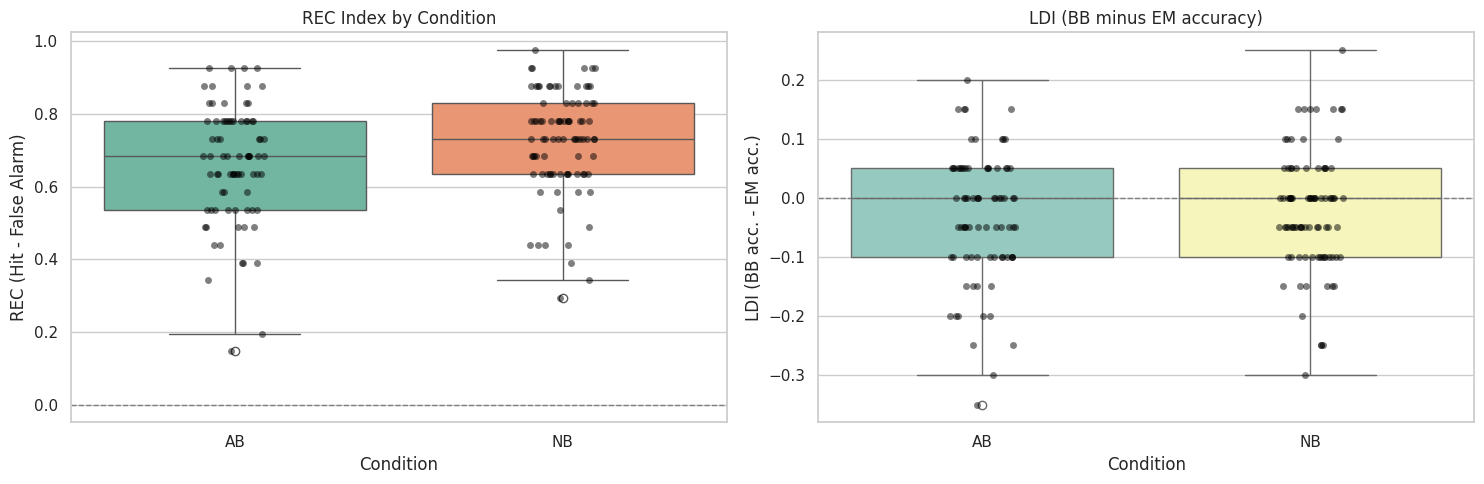

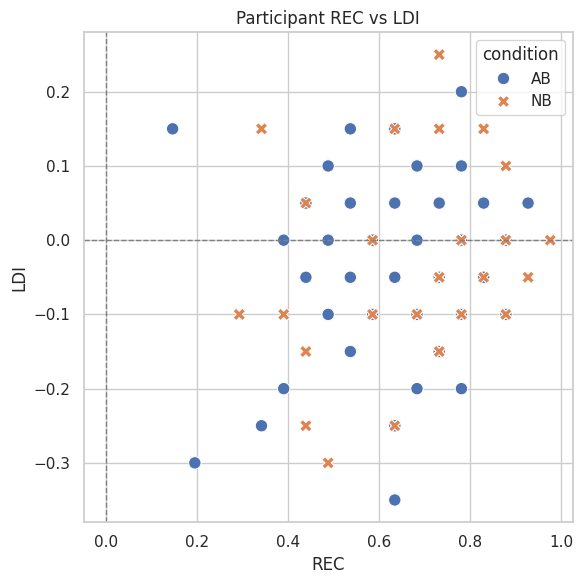

In [106]:
import numpy as np

# Locate the response-accuracy column (fallback to common names if the helper variable is absent)
def pick_column(candidates, df):
    for candidate in candidates:
        if candidate in df.columns:
            return candidate
    raise KeyError(f"None of the candidate columns {candidates} exist in the provided DataFrame.")

accuracy_candidates = ['recogloop.resp.corr', 'Resp.corr', 'resp.corr']
corr_source = (
    corr_col
    if 'corr_col' in globals() and corr_col in recog_data.columns
    else pick_column(accuracy_candidates, recog_data)
)

index_trials = recog_data.dropna(subset=[corr_source, 'condition', 'participant_id']).copy()
index_trials[corr_source] = pd.to_numeric(index_trials[corr_source], errors='coerce')
index_trials = index_trials.dropna(subset=[corr_source])
index_trials['condition'] = index_trials['condition'].str.upper()

if 'target_type' not in index_trials.columns or index_trials['target_type'].isna().all():
    index_trials['target_type'] = index_trials['target_img'].apply(extract_target_type)


def summarize_rec_ldi(df, resp_col):
    records = []
    for (pid, cond), subset in df.groupby(['participant_id', 'condition']):
        trials = subset[resp_col].dropna()
        n_trials = len(trials)
        if not n_trials:
            continue
        hits = trials.sum()
        misses = n_trials - hits
        hit_rate = hits / n_trials
        false_alarm_rate = misses / n_trials

        # Log-linear correction (Hautus, 1995) to stabilize extremes
        hit_adj = (hits + 0.5) / (n_trials + 1)
        fa_adj = (misses + 0.5) / (n_trials + 1)
        rec_index = hit_adj - fa_adj

        bb_rate = subset.loc[subset['target_type'] == 'BB', resp_col].mean()
        em_rate = subset.loc[subset['target_type'] == 'EM', resp_col].mean()
        ldi = bb_rate - em_rate if pd.notna(bb_rate) and pd.notna(em_rate) else np.nan

        records.append({
            'participant_id': pid,
            'condition': cond,
            'n_trials': n_trials,
            'hit_rate': hit_rate,
            'false_alarm_rate': false_alarm_rate,
            'rec_index': rec_index,
            'bb_accuracy': bb_rate,
            'em_accuracy': em_rate,
            'ldi': ldi
        })
    return pd.DataFrame(records)

rec_summary = summarize_rec_ldi(index_trials, corr_source)
print('Participant-level REC/LDI preview:')
display(rec_summary.head())

condition_summary = (
    rec_summary.groupby('condition')[['rec_index', 'ldi']]
    .agg(['mean', 'std', 'median', 'count'])
    .round(3)
)
print('\nCondition-wise REC/LDI summary:')
display(condition_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
if not rec_summary.empty:
    sns.boxplot(data=rec_summary, x='condition', y='rec_index', palette='Set2', ax=axes[0])
    sns.stripplot(data=rec_summary, x='condition', y='rec_index', color='black', alpha=0.5, jitter=0.1, ax=axes[0])
    axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[0].set_title('REC Index by Condition')
    axes[0].set_ylabel('REC (Hit - False Alarm)')
    axes[0].set_xlabel('Condition')

    sns.boxplot(data=rec_summary, x='condition', y='ldi', palette='Set3', ax=axes[1])
    sns.stripplot(data=rec_summary, x='condition', y='ldi', color='black', alpha=0.5, jitter=0.1, ax=axes[1])
    axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[1].set_title('LDI (BB minus EM accuracy)')
    axes[1].set_ylabel('LDI (BB acc. - EM acc.)')
    axes[1].set_xlabel('Condition')
else:
    axes[0].text(0.5, 0.5, 'No recognition trials available', ha='center', va='center')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

if not rec_summary.empty:
    fig, ax = plt.subplots(figsize=(6, 6))
    sns.scatterplot(data=rec_summary, x='rec_index', y='ldi', hue='condition', style='condition', s=80, ax=ax)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title('Participant REC vs LDI')
    ax.set_xlabel('REC')
    ax.set_ylabel('LDI')
    plt.tight_layout()
    plt.show()
else:
    print('REC/LDI scatter skipped because no participant data were available.')

In [108]:
import base64
import nbformat

# Save already-generated inline plot outputs without re-running the notebook
notebook_path = Path('visualisation.ipynb')
inline_dir = plot_dir / 'inline_outputs'
inline_dir.mkdir(parents=True, exist_ok=True)

with notebook_path.open('r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

saved = 0
for cell_idx, cell in enumerate(nb.cells, start=1):
    if cell.get('cell_type') != 'code':
        continue
    for out_idx, output in enumerate(cell.get('outputs', []), start=1):
        data = output.get('data', {}) if isinstance(output, dict) else {}
        if 'image/png' in data:
            img_bytes = base64.b64decode(data['image/png'])
            out_path = inline_dir / f'cell{cell_idx:03d}_out{out_idx:02d}.png'
            out_path.write_bytes(img_bytes)
            saved += 1
        elif 'image/jpeg' in data:
            img_bytes = base64.b64decode(data['image/jpeg'])
            out_path = inline_dir / f'cell{cell_idx:03d}_out{out_idx:02d}.jpg'
            out_path.write_bytes(img_bytes)
            saved += 1
        elif 'image/svg+xml' in data:
            out_path = inline_dir / f'cell{cell_idx:03d}_out{out_idx:02d}.svg'
            out_path.write_text(data['image/svg+xml'], encoding='utf-8')
            saved += 1

if saved:
    print(f"Saved {saved} inline plot file(s) to: {inline_dir.resolve()}")
else:
    print('No inline image outputs found. Run the plotting cells first, then rerun this saver cell.')


Saved 16 inline plot file(s) to: /home/yash/Public/Sem-8/BRSM/Project/Movie-Memory-Analysis/analysis_plots/inline_outputs


### Interpretation of REC/LDI Outputs
- **Overall recognition (REC):** After log-linear smoothing, mean REC = 0.661 for Abrupt (AB, *n*=80) and 0.725 for Natural (NB, *n*=89). The medians (0.683 vs 0.732) fall well above zero, confirming that both groups reliably pick targets over lures. The NB group’s slightly higher mean (Δ=0.064) aligns with the box plots, which show more NB participants clustering near 0.8–0.9.
- **Hit vs miss composition:** Within participants, raw hit rates average 85% (AB) and 90% (NB), while miss-driven false alarms average 15% vs 10%, explaining most of the REC gap.
- **Lure Discrimination proxy (LDI = BB – EM accuracy):** Means hover near zero (AB = −0.032, NB = −0.024) with medians exactly 0, indicating that boundary-adjacent (BB) frames are not reliably easier or harder than event-middle (EM) frames once responses are forced-choice. The spread (std ≈ 0.10) shows individual differences: some participants exceed +0.2 in favor of BB, others dip below −0.2 (EM advantage).
- **Joint pattern:** The REC–LDI scatter highlights that high discriminators (REC > 0.8) exist in both conditions, and their LDI values still straddle zero. Thus, better overall recognition does not automatically translate to BB-specific benefits in this dataset.
- **Takeaway:** Natural-cut exposure modestly boosts recognition accuracy, but boundary sensitivity appears participant-specific rather than condition-driven. 